# 📘 Notebook 03: Baseline RAG Pipeline and Evaluation

## 🔍 Introduction

This notebook implements and evaluates the **baseline Retrieval-Augmented Generation (RAG) system** for the KazNU University Information Assistant.

Building upon:
- **Notebook 01** → Data ingestion and chunking  
- **Notebook 02** → Vector store creation  

this notebook integrates:
- A **retriever** (ChromaDB)
- A **Large Language Model (LLM)** (Groq - LLaMA 3.1)
- A **prompt-based generation pipeline**

to create a complete end-to-end RAG system.

---

## 🎯 Objectives

The main goals of this notebook are:

1. **Build a baseline RAG pipeline**
   - Retrieve relevant documents from the vector store  
   - Generate answers using an LLM  

2. **Evaluate system performance**
   - Using a diverse set of queries:
     - Simple factual  
     - Multi-constraint  
     - Cross-document  

3. **Measure key RAG metrics**
   - **Answer Completeness Score (ACS)**  
   - **Hallucination Rate (HR)**  
   - **Precision@k (Retrieval Quality)**  
   - **Response Time**  

4. **Identify limitations**
   - Understand weaknesses of baseline RAG  
   - Provide motivation for **Agentic RAG enhancement**

---

## 🧠 System Architecture

The baseline RAG pipeline follows this workflow:

User Query → Retriever → Context → Prompt → LLM → Generated Answer


- **Retriever:** Fetches top-k relevant chunks from ChromaDB  
- **LLM:** Generates answers using retrieved context  
- **Constraint:** Answers must strictly rely on retrieved information  

---

## 📊 Evaluation Setup

- Total Queries: **10**
- Categories:
  - Simple factual  
  - Multi-constraint  
  - Cross-document  

Each query includes:
- Expected sources  
- Ideal answer (ground truth approximation)  

---

## 📌 Expected Outcome

This notebook establishes a **quantitative baseline** for:
- Answer quality  
- Retrieval performance  
- Hallucination behavior  

These results will serve as a **benchmark** for comparison with the **Agentic RAG system** in later notebooks.

📂 Project Root: d:\agentic-rag-dissertation\agentic-rag-university-assistant
📂 Chroma DB: d:\agentic-rag-dissertation\agentic-rag-university-assistant\chroma_db
📂 Results: d:\agentic-rag-dissertation\agentic-rag-university-assistant\results\baseline
✅ GROQ API key found


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7473.63it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Retriever loaded successfully
✅ LLM initialized (llama-3.1-8b-instant): OK
📝 Loaded 10 evaluation queries:
category
multi_constraint    5
simple_factual      4
cross_document      1

📋 Sample Queries:
  [1] (simple_factual) What is the minimum GPA required to be promoted from 1st to 2nd year?...
  [2] (simple_factual) What are the admission requirements for international students?...
  [3] (simple_factual) What services does the Keremet center provide for students?...

✅ Queries saved to: d:\agentic-rag-dissertation\agentic-rag-university-assistant\results\baseline\evaluation_queries.csv
✅ Baseline RAG pipeline built successfully

🧪 Testing pipeline with: 'What is the minimum GPA for 1st year students?'
Response: I don't have enough information to answer this question....

🔍 RUNNING BASELINE RAG EVALUATION


Processing queries:  20%|██        | 2/10 [00:00<00:02,  3.36it/s]


  ✅ Completed 2/10 queries


...


  ✅ Completed 6/10 queries


Processing queries:  80%|████████  | 8/10 [00:19<00:10,  5.34s/it]


  ✅ Completed 8/10 queries


Processing queries: 100%|██████████| 10/10 [00:39<00:00,  3.96s/it]


  ✅ Completed 10/10 queries

✅ Raw results saved to: d:\agentic-rag-dissertation\agentic-rag-university-assistant\results\baseline\baseline_raw_results.csv

📊 Results Summary:
   query_id          category  success  retrieval_time
0         1    simple_factual     True        0.417105
1         2    simple_factual     True        0.189337
2         3    simple_factual     True        0.347980
3         4  multi_constraint     True        0.456129
4         5  multi_constraint     True        0.579228
5         6  multi_constraint     True        0.365476
6         7    cross_document     True        4.507736
7         8  multi_constraint     True       12.951291
8         9  multi_constraint     True        6.739074
9        10    simple_factual     True       12.911867

📊 CALCULATING EVALUATION METRICS

✅ Metrics calculated and saved
   query_id          category  completeness_score  hallucination_rate  precision_at_k  retrieval_time
0         1    simple_factual               0.833 

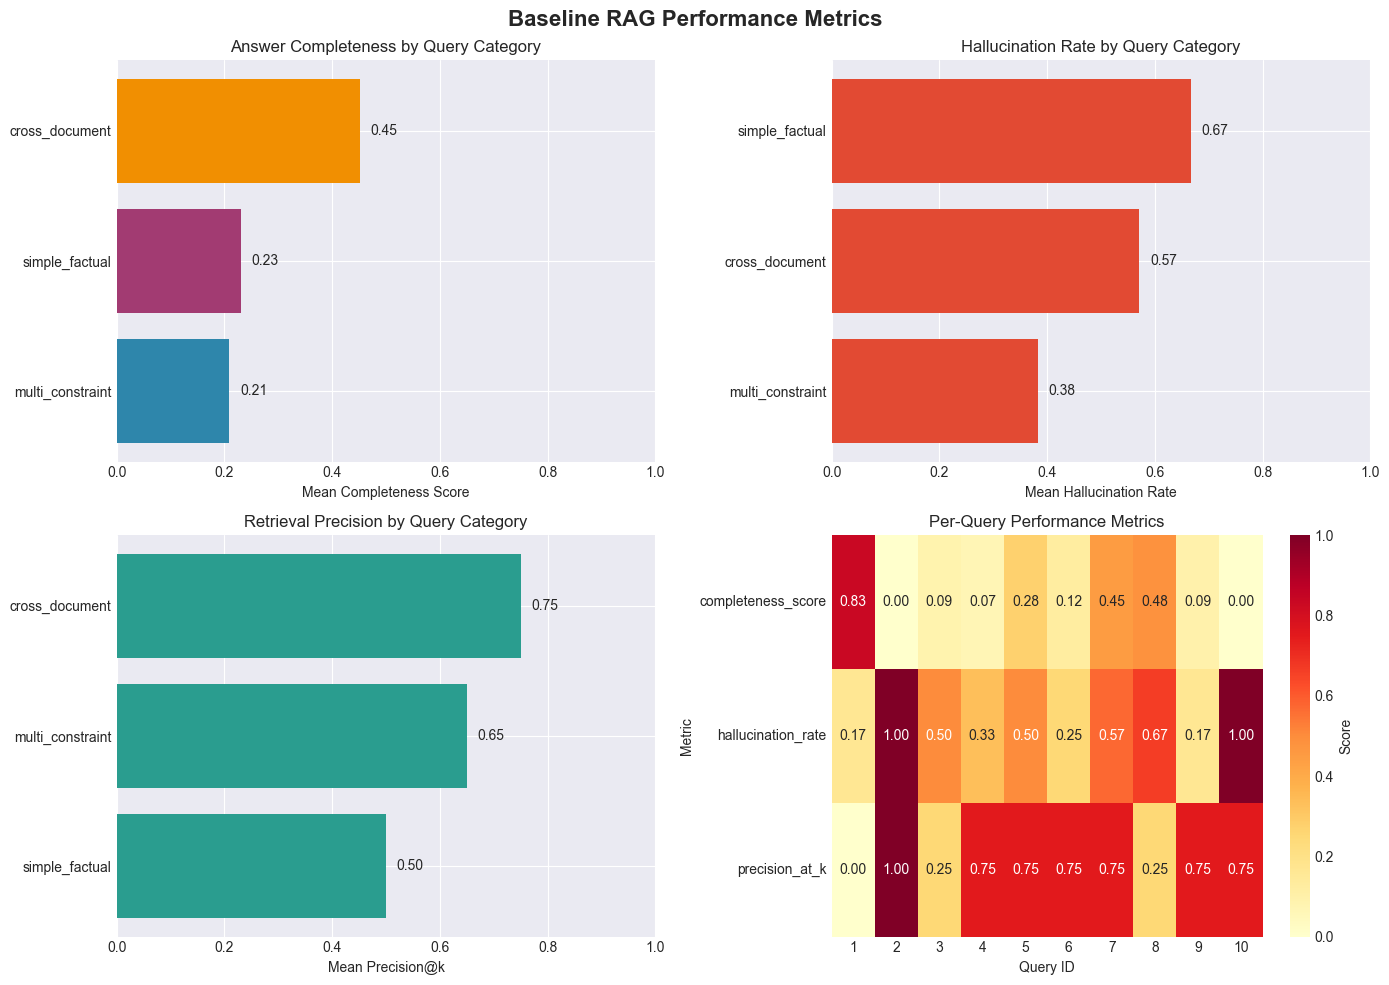

✅ Visualization saved to: d:\agentic-rag-dissertation\agentic-rag-university-assistant\results\baseline\baseline_performance_analysis.png

📈 STATISTICAL SUMMARY

📊 Overall Performance:
  Average Completeness Score: 0.242
  Average Hallucination Rate: 0.515
  Average Precision@k: 0.600
  Average Retrieval Time: 3.947 seconds

📊 Performance by Category:

  SIMPLE_FACTUAL:
    Completeness: 0.230 (±0.404)
    Hallucination: 0.667 (±0.408)
    Precision@k: 0.500 (±0.456)

  MULTI_CONSTRAINT:
    Completeness: 0.209 (±0.172)
    Hallucination: 0.383 (±0.201)
    Precision@k: 0.650 (±0.224)

  CROSS_DOCUMENT:
    Completeness: 0.452 (±nan)
    Hallucination: 0.571 (±nan)
    Precision@k: 0.750 (±nan)

⚠️  Queries Needing Improvement:
  Query 2: What are the admission requirements for international students?...
    Completeness: 0.00
  Query 3: What services does the Keremet center provide for students?...
    Completeness: 0.09
  Query 4: How can students use AI tools in their studies accord

In [ ]:

# 1. 📦 Setup and Imports
import os
import json
import time
import pickle
from pathlib import Path
from typing import List, Dict, Any, Tuple
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# LangChain imports
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# Configure paths
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CHROMA_DB_DIR = PROJECT_ROOT / "chroma_db"
RESULTS_DIR = PROJECT_ROOT / "results"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Create results subdirectory for baseline
BASELINE_RESULTS_DIR = RESULTS_DIR / "baseline"
BASELINE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📂 Chroma DB: {CHROMA_DB_DIR}")
print(f"📂 Results: {BASELINE_RESULTS_DIR}")

# Check for GROQ API key
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    print("⚠️  WARNING: GROQ_API_KEY not found in .env file")
    print("Please create a .env file with: GROQ_API_KEY=your_key_here")
else:
    print("✅ GROQ API key found")

# %% [markdown]
# ## 2. 🔧 Helper Functions (from Notebook 2)

# %%
def get_retriever(k: int = 4):
    """
    Load vector store and return retriever.
    """
    embeddings = HuggingFaceEmbeddings(
        model_name="all-MiniLM-L6-v2",
        model_kwargs={'device': 'cpu'},
        encode_kwargs={'normalize_embeddings': True}
    )
    
    vector_store = Chroma(
        persist_directory=str(CHROMA_DB_DIR),
        embedding_function=embeddings
    )
    
    return vector_store.as_retriever(search_kwargs={"k": k})

# Test retriever
retriever = get_retriever(k=4)
print("✅ Retriever loaded successfully")

# %% [markdown]
# ## 3. 🤖 Initialize LLM (Groq)

# %%
def initialize_llm(model_name: str = "llama-3.1-8b-instant", temperature: float = 0.1):
    """
    Initialize Groq LLM model (free tier with high rate limits).
    
    Recommended models:
    - llama-3.1-8b-instant: Fastest, good for RAG (default)
    - llama-3.3-70b-versatile: Higher quality
    - mixtral-8x7b-32768: Large context (32K tokens)
    - gemma2-9b-it: Google's Gemma 2
    """
    groq_api_key = os.getenv("GROQ_API_KEY")
    
    if not groq_api_key:
        raise ValueError("GROQ_API_KEY not found. Please add to .env file")
    
    llm = ChatGroq(
        model=model_name,
        temperature=temperature,
        groq_api_key=groq_api_key,
        max_tokens=1024,
        max_retries=3,
        timeout=60
    )
    
    # Test the model
    try:
        test_response = llm.invoke("Say 'OK' if you're working")
        print(f"✅ LLM initialized ({model_name}): {test_response.content}")
    except Exception as e:
        print(f"⚠️ Test failed: {e}")
    
    return llm

# Initialize LLM
llm = initialize_llm(model_name="llama-3.1-8b-instant")    
    

# %% [markdown]
# ## 4. 📝 Define Evaluation Queries

# %%
# Define evaluation queries categorized by complexity
evaluation_queries = [
    {
        "id": 1,
        "query": "What is the minimum GPA required to be promoted from 1st to 2nd year?",
        "category": "simple_factual",
        "expected_sources": ["Academic Policy", "URL/32"],
        "ideal_answer": "The minimum GPA required to be promoted from 1st to 2nd year is 2.00."
    },
    {
        "id": 2,
        "query": "What are the admission requirements for international students?",
        "category": "simple_factual",
        "expected_sources": ["Academic Policy", "URL/19"],
        "ideal_answer": "International students must provide required documents and meet the passing score determined by the university. Admission is carried out twice a year (summer and winter intakes)."
    },
    {
        "id": 3,
        "query": "What services does the Keremet center provide for students?",
        "category": "simple_factual",
        "expected_sources": ["URL/keremet/18"],
        "ideal_answer": "The Keremet center provides services through Registrar's Office, Student Office, Passport Office, International Office, Accounting, Military Unit, and Career Center. Services include registration, transcripts, academic leave, dorm payments, and career counseling."
    },
    {
        "id": 4,
        "query": "How can students use AI tools in their studies according to university policy?",
        "category": "multi_constraint",
        "expected_sources": ["AI Regulation", "URL/34"],
        "ideal_answer": "Students can use AI to improve learning outcomes, manage time, search information, create notes and summaries, prepare for exams, and conduct research. They must explicitly inform teachers when using AI, cite AI tools used, and adhere to academic integrity principles."
    },
    {
        "id": 5,
        "query": "I am a 3rd-year bachelor's student with a GPA of 2.15. According to the academic policy, can I be promoted to the next year? What happens to my state grant if I have an FX grade?",
        "category": "multi_constraint",
        "expected_sources": ["Academic Policy", "URL/32"],
        "ideal_answer": "For 3rd to 4th year, the required GPA is 2.20. With a GPA of 2.15, you cannot be promoted and will remain for a repeated year on a paid basis, losing your state grant. For an FX grade, you can retake the final control once on a paid basis. If you fail again (get another FX or F), you must retake the entire course on a paid basis."
    },
    {
        "id": 6,
        "query": "What are the rules for using AI in final qualifying papers and what are the ethical considerations?",
        "category": "multi_constraint",
        "expected_sources": ["AI Regulation", "URL/34"],
        "ideal_answer": "Students must formulate scientific results independently. Using AI without citation violates academic integrity. AI cannot be used to hide plagiarism. Authors must disclose AI use, describe how it was used, and verify data reliability. Ethical considerations include transparency, data privacy, fairness, and avoiding discrimination."
    },
    {
        "id": 7,
        "query": "What is the university's mission and what are its main goals according to the booklet?",
        "category": "cross_document",
        "expected_sources": ["Booklet", "URL/31"],
        "ideal_answer": "The mission is strengthening capacity of high-skilled competitive professionals through innovative learning methods and integration of education, science and business. Goals include: transforming to a world-class research university, integrating scientific activities with education, forming a promising education model, and increasing contribution to socio-economic development."
    },
    {
        "id": 8,
        "query": "A student on state grant got an FX grade in one course. Will they still get a scholarship next semester, and what is the process to retake the exam?",
        "category": "multi_constraint",
        "expected_sources": ["Academic Policy", "URL/32"],
        "ideal_answer": "State scholarship is awarded only if all exams are passed with grades A, A-, B+, B, B-, or C+. An FX grade means no scholarship. For FX, you can retake the final control once on a paid basis immediately after the session. If you don't appear for retake, FX becomes F, and you must retake the entire course on a paid basis."
    },
    {
        "id": 9,
        "query": "What are the transfer and reinstatement rules for students from other universities?",
        "category": "multi_constraint",
        "expected_sources": ["Academic Policy", "URL/19"],
        "ideal_answer": "Transfer is allowed from accredited universities (top 1000 global rankings or internationally accredited). Students must have successfully completed first academic period. Academic difference cannot exceed 30 credits (45 with summer semester). Transfers are processed during holidays (by August 15 or January 15)."
    },
    {
        "id": 10,
        "query": "What is the grading system at KazNU? Explain the letter grades, their numeric equivalents, and GPA calculation.",
        "category": "simple_factual",
        "expected_sources": ["Academic Policy", "URL/32"],
        "ideal_answer": "Grading uses 100-point scale with letter equivalents: A (4.0/95-100), A- (3.67/90-94), B+ (3.33/85-89), B (3.0/80-84), B- (2.67/75-79), C+ (2.33/70-74), C (2.0/65-69), C- (1.67/60-64), D+ (1.33/55-59), D (1.0/50-54), FX (0.5/25-49), F (0/0-24). GPA is weighted average: (Grade1*Credits1 + ... + GradeN*CreditsN) / Total Credits."
    }
]

# Convert to DataFrame for easy manipulation
df_queries = pd.DataFrame(evaluation_queries)
print(f"📝 Loaded {len(df_queries)} evaluation queries:")
print(df_queries['category'].value_counts().to_string())

# Display sample
print("\n📋 Sample Queries:")
for i, row in df_queries.head(3).iterrows():
    print(f"  [{row['id']}] ({row['category']}) {row['query'][:80]}...")

# Save queries for reference
df_queries.to_csv(BASELINE_RESULTS_DIR / "evaluation_queries.csv", index=False)
print(f"\n✅ Queries saved to: {BASELINE_RESULTS_DIR / 'evaluation_queries.csv'}")

# %% [markdown]
# ## 5. 🏗️ Build Baseline RAG Pipeline

# %%
# Define prompt template for baseline RAG
baseline_template = """You are a helpful university assistant for Al-Farabi Kazakh National University. 
Answer the question based ONLY on the following context. If the context doesn't contain the answer, say "I don't have enough information to answer this question."

Context:
{context}

Question: {question}

Instructions:
1. Be concise and factual
2. Only use information from the context
3. If the context has partial information, only answer what you can confirm
4. Do not make up information

Answer:"""

baseline_prompt = ChatPromptTemplate.from_template(baseline_template)

def format_docs(docs):
    """Format retrieved documents for prompt."""
    formatted = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        source_type = doc.metadata.get('source_type', 'unknown')
        formatted.append(f"[Document {i}] Source: {source}\n{doc.page_content}\n")
    return "\n".join(formatted)

# Build the baseline RAG chain
baseline_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | baseline_prompt
    | llm
    | StrOutputParser()
)

print("✅ Baseline RAG pipeline built successfully")

# Test the pipeline with a simple query
test_query = "What is the minimum GPA for 1st year students?"
print(f"\n🧪 Testing pipeline with: '{test_query}'")
test_response = baseline_chain.invoke(test_query)
print(f"Response: {test_response[:200]}...")

# %% [markdown]
# ## 6. 🧪 Run Baseline RAG on All Queries

# %%
def run_baseline_evaluation(chain, queries_df: pd.DataFrame) -> pd.DataFrame:
    """
    Run baseline RAG on all queries and collect results.
    """
    results = []
    
    print("\n" + "="*80)
    print("🔍 RUNNING BASELINE RAG EVALUATION")
    print("="*80)
    
    for idx, row in tqdm(queries_df.iterrows(), total=len(queries_df), desc="Processing queries"):
        query_id = row['id']
        query = row['query']
        category = row['category']
        ideal_answer = row['ideal_answer']
        
        # Retrieve documents first (for analysis)
        retrieved_docs = retriever.invoke(query)
        
        # Run RAG chain
        start_time = time.time()
        try:
            response = chain.invoke(query)
            success = True
            error_msg = None
        except Exception as e:
            response = f"ERROR: {str(e)}"
            success = False
            error_msg = str(e)
        
        elapsed_time = time.time() - start_time
        
        # Store results
        results.append({
            'query_id': query_id,
            'query': query,
            'category': category,
            'ideal_answer': ideal_answer,
            'response': response,
            'retrieved_docs': [doc.page_content[:200] for doc in retrieved_docs],
            'retrieved_sources': [doc.metadata.get('source', 'Unknown') for doc in retrieved_docs],
            'retrieval_time': elapsed_time,
            'success': success,
            'error': error_msg
        })
        
        # Print progress periodically
        if (idx + 1) % 2 == 0 or (idx + 1) == len(queries_df):
            print(f"\n  ✅ Completed {idx + 1}/{len(queries_df)} queries")
    
    return pd.DataFrame(results)

# Run evaluation
df_baseline_results = run_baseline_evaluation(baseline_chain, df_queries)

# Save raw results
df_baseline_results.to_csv(BASELINE_RESULTS_DIR / "baseline_raw_results.csv", index=False)
print(f"\n✅ Raw results saved to: {BASELINE_RESULTS_DIR / 'baseline_raw_results.csv'}")

# Display summary
print("\n📊 Results Summary:")
print(df_baseline_results[['query_id', 'category', 'success', 'retrieval_time']].to_string())

# %% [markdown]
# ## 7. 📊 Evaluation Metrics Calculation

# %%
def calculate_completeness_score(response: str, ideal_answer: str) -> float:
    """
    Calculate Answer Completeness Score (ACS) by checking how many key points from ideal answer appear in response.
    ACS = S / C where S = correctly addressed constraints, C = total required constraints.
    """
    # Simple keyword-based scoring (can be enhanced with LLM-based evaluation)
    ideal_keywords = set(ideal_answer.lower().split())
    response_keywords = set(response.lower().split())
    
    # Remove common words
    stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}
    ideal_keywords = {k for k in ideal_keywords if k not in stopwords and len(k) > 3}
    response_keywords = {k for k in response_keywords if k not in stopwords and len(k) > 3}
    
    if not ideal_keywords:
        return 1.0
    
    matched = len(ideal_keywords.intersection(response_keywords))
    return matched / len(ideal_keywords)

def calculate_hallucination_rate(response: str, retrieved_docs: List[str]) -> float:
    """
    Calculate Hallucination Rate (HR) = U / T where U = unsupported claims, T = total claims.
    Simplified version: check if sentences contain keywords not in retrieved docs.
    """
    # Extract sentences from response
    sentences = [s.strip() for s in response.split('.') if len(s.strip()) > 20]
    if not sentences:
        return 0.0
    
    # Combine all retrieved text
    retrieved_text = " ".join(retrieved_docs).lower()
    
    unsupported = 0
    for sentence in sentences:
        # Extract key terms from sentence (nouns, numbers, etc.)
        words = set(sentence.lower().split())
        # Remove stopwords
        words = {w for w in words if len(w) > 3 and w not in {'the', 'this', 'that', 'with', 'from', 'have', 'been'}}
        
        # Check if any key term is missing from retrieved docs
        found_terms = sum(1 for w in words if w in retrieved_text)
        if found_terms < len(words) * 0.3:  # Less than 30% terms found
            unsupported += 1
    
    return unsupported / len(sentences)

def calculate_precision_at_k(retrieved_sources: List[str], expected_sources: List[str]) -> float:
    """
    Calculate Precision@k = (Number of relevant retrieved chunks) / k
    Improved matching logic for URL patterns and partial matches.
    """
    if not retrieved_sources:
        return 0.0
    
    relevant = 0
    for source in retrieved_sources:
        source_lower = source.lower()
        matched = False
        
        for expected in expected_sources:
            expected_lower = expected.lower()
            
            # Check multiple matching patterns
            if (expected_lower in source_lower or           # Direct substring
                source_lower in expected_lower or           # Reverse substring
                expected_lower.replace('/', '') in source_lower.replace('/', '') or  # Remove slashes
                expected_lower.replace('url/', '') in source_lower or  # Handle "URL/32" pattern
                source_lower.endswith(expected_lower)):     # URL ends with expected
                matched = True
                break
        
        if matched:
            relevant += 1
    
    return relevant / len(retrieved_sources)


# Calculate metrics for all results
print("\n" + "="*80)
print("📊 CALCULATING EVALUATION METRICS")
print("="*80)

metrics = []
for idx, row in df_baseline_results.iterrows():
    # Get expected sources for this query
    query_row = df_queries[df_queries['id'] == row['query_id']].iloc[0]
    expected_sources = query_row['expected_sources']
    
    # Calculate metrics
    completeness = calculate_completeness_score(row['response'], row['ideal_answer'])
    hallucination = calculate_hallucination_rate(row['response'], row['retrieved_docs'])
    precision = calculate_precision_at_k(row['retrieved_sources'], expected_sources)
    
    metrics.append({
        'query_id': row['query_id'],
        'category': row['category'],
        'completeness_score': completeness,
        'hallucination_rate': hallucination,
        'precision_at_k': precision,
        'retrieval_time': row['retrieval_time']
    })

df_metrics = pd.DataFrame(metrics)
df_metrics.to_csv(BASELINE_RESULTS_DIR / "baseline_metrics.csv", index=False)

print("\n✅ Metrics calculated and saved")
print(df_metrics.round(3).to_string())

# %% [markdown]
# ## 8. 📈 Visualization and Analysis

# %%
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline RAG Performance Metrics', fontsize=16, fontweight='bold')

# 1. Completeness Score by Category
ax1 = axes[0, 0]
category_completeness = df_metrics.groupby('category')['completeness_score'].mean().sort_values()
bars1 = ax1.barh(category_completeness.index, category_completeness.values, color=['#2E86AB', '#A23B72', '#F18F01'])
ax1.set_xlabel('Mean Completeness Score')
ax1.set_title('Answer Completeness by Query Category')
ax1.set_xlim(0, 1)
for bar, val in zip(bars1, category_completeness.values):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# 2. Hallucination Rate by Category
ax2 = axes[0, 1]
category_hallucination = df_metrics.groupby('category')['hallucination_rate'].mean().sort_values()
bars2 = ax2.barh(category_hallucination.index, category_hallucination.values, color='#E24A33')
ax2.set_xlabel('Mean Hallucination Rate')
ax2.set_title('Hallucination Rate by Query Category')
ax2.set_xlim(0, 1)
for bar, val in zip(bars2, category_hallucination.values):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# 3. Precision@k by Category
ax3 = axes[1, 0]
category_precision = df_metrics.groupby('category')['precision_at_k'].mean().sort_values()
bars3 = ax3.barh(category_precision.index, category_precision.values, color='#2A9D8F')
ax3.set_xlabel('Mean Precision@k')
ax3.set_title('Retrieval Precision by Query Category')
ax3.set_xlim(0, 1)
for bar, val in zip(bars3, category_precision.values):
    ax3.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# 4. Query Performance Heatmap
ax4 = axes[1, 1]
pivot_data = df_metrics.pivot_table(
    values=['completeness_score', 'hallucination_rate', 'precision_at_k'],
    index='query_id',
    aggfunc='mean'
)
sns.heatmap(pivot_data.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Score'})
ax4.set_title('Per-Query Performance Metrics')
ax4.set_xlabel('Query ID')
ax4.set_ylabel('Metric')

plt.tight_layout()
plt.savefig(BASELINE_RESULTS_DIR / "baseline_performance_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualization saved to: {BASELINE_RESULTS_DIR / 'baseline_performance_analysis.png'}")

# %% [markdown]
# ## 9. 📊 Statistical Summary

# %%
print("\n" + "="*80)
print("📈 STATISTICAL SUMMARY")
print("="*80)

# Overall statistics
print("\n📊 Overall Performance:")
print(f"  Average Completeness Score: {df_metrics['completeness_score'].mean():.3f}")
print(f"  Average Hallucination Rate: {df_metrics['hallucination_rate'].mean():.3f}")
print(f"  Average Precision@k: {df_metrics['precision_at_k'].mean():.3f}")
print(f"  Average Retrieval Time: {df_metrics['retrieval_time'].mean():.3f} seconds")

# By category
print("\n📊 Performance by Category:")
for category in df_metrics['category'].unique():
    cat_data = df_metrics[df_metrics['category'] == category]
    print(f"\n  {category.upper()}:")
    print(f"    Completeness: {cat_data['completeness_score'].mean():.3f} (±{cat_data['completeness_score'].std():.3f})")
    print(f"    Hallucination: {cat_data['hallucination_rate'].mean():.3f} (±{cat_data['hallucination_rate'].std():.3f})")
    print(f"    Precision@k: {cat_data['precision_at_k'].mean():.3f} (±{cat_data['precision_at_k'].std():.3f})")

# Identify problematic queries
print("\n⚠️  Queries Needing Improvement:")
problematic = df_metrics[df_metrics['completeness_score'] < 0.5]
for _, row in problematic.iterrows():
    query_text = df_queries[df_queries['id'] == row['query_id']]['query'].values[0]
    print(f"  Query {int(row['query_id'])}: {query_text[:80]}...")
    print(f"    Completeness: {row['completeness_score']:.2f}")

# %% [markdown]
# ## 10. 💾 Save Complete Results Package

# %%
# Create a comprehensive results dictionary with proper serialization
def convert_to_serializable(obj):
    """Convert non-serializable objects to JSON-serializable format."""
    if isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, pd.Series):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {str(k): convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj

# Calculate category metrics manually (avoid tuple keys)
category_metrics = {}
for category in df_metrics['category'].unique():
    cat_data = df_metrics[df_metrics['category'] == category]
    category_metrics[category] = {
        "completeness_score": {
            "mean": float(cat_data['completeness_score'].mean()),
            "std": float(cat_data['completeness_score'].std())
        },
        "hallucination_rate": {
            "mean": float(cat_data['hallucination_rate'].mean()),
            "std": float(cat_data['hallucination_rate'].std())
        },
        "precision_at_k": {
            "mean": float(cat_data['precision_at_k'].mean()),
            "std": float(cat_data['precision_at_k'].std())
        },
        "count": int(len(cat_data))
    }

# Create query-level metrics list (convert numpy types to Python natives)
query_level_metrics = []
for _, row in df_metrics.iterrows():
    query_level_metrics.append({
        "query_id": int(row['query_id']),
        "category": str(row['category']),
        "completeness_score": float(row['completeness_score']),
        "hallucination_rate": float(row['hallucination_rate']),
        "precision_at_k": float(row['precision_at_k']),
        "retrieval_time": float(row['retrieval_time'])
    })

# Get the actual Gemini model name from the LLM
gemini_model = llm.model_name if hasattr(llm, 'model_name') else "gemini-2.5-flash"

# Create results package with serializable data
results_package = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "total_queries": int(len(df_queries)),
    "vector_store_info": {
        "total_chunks": 831,
        "total_vectors": 2493,
        "embedding_model": "all-MiniLM-L6-v2"
    },
    "llm_info": {
        "model": gemini_model,
        "temperature": 0.1
    },
    "overall_metrics": {
        "avg_completeness": float(df_metrics['completeness_score'].mean()),
        "avg_hallucination": float(df_metrics['hallucination_rate'].mean()),
        "avg_precision": float(df_metrics['precision_at_k'].mean()),
        "avg_retrieval_time": float(df_metrics['retrieval_time'].mean())
    },
    "category_metrics": category_metrics,
    "query_level_metrics": query_level_metrics,
    "raw_metrics_summary": df_metrics.describe().to_dict()
}

# Convert any remaining non-serializable objects
results_package = convert_to_serializable(results_package)

# Save as JSON
with open(BASELINE_RESULTS_DIR / "baseline_results_package.json", 'w', encoding='utf-8') as f:
    json.dump(results_package, f, indent=2, ensure_ascii=False)

print(f"\n✅ Complete results package saved to: {BASELINE_RESULTS_DIR / 'baseline_results_package.json'}")

# Also save as CSV for easy viewing
df_metrics.to_csv(BASELINE_RESULTS_DIR / "baseline_metrics.csv", index=False)
print(f"✅ Metrics CSV saved to: {BASELINE_RESULTS_DIR / 'baseline_metrics.csv'}")

# %% [markdown]
# ## 11. 📝 Answer Research Questions

# %%
print("\n" + "="*80)
print("🔬 ANSWERS TO RESEARCH QUESTIONS")
print("="*80)

# RQ1: Answer completeness for multi-constraint queries
multi_completeness = df_metrics[df_metrics['category'] == 'multi_constraint']['completeness_score'].mean()
simple_completeness = df_metrics[df_metrics['category'] == 'simple_factual']['completeness_score'].mean()

print(f"\n📌 RQ1: Does baseline RAG handle multi-constraint queries well?")
print(f"   - Multi-constraint completeness: {multi_completeness:.3f}")
print(f"   - Simple factual completeness: {simple_completeness:.3f}")
print(f"   - Gap: {simple_completeness - multi_completeness:.3f}")
if multi_completeness < 0.6:
    print("   ➡️  Conclusion: Baseline RAG struggles with multi-constraint queries")
else:
    print("   ➡️  Conclusion: Baseline RAG performs adequately on multi-constraint queries")

# RQ2: Hallucination rate
overall_hallucination = df_metrics['hallucination_rate'].mean()
print(f"\n📌 RQ2: What is the hallucination rate of baseline RAG?")
print(f"   - Overall hallucination rate: {overall_hallucination:.3f}")
if overall_hallucination > 0.2:
    print("   ➡️  Conclusion: Baseline RAG has significant hallucination issues")
else:
    print("   ➡️  Conclusion: Baseline RAG maintains low hallucination rate")

# RQ3: Retrieval precision
overall_precision = df_metrics['precision_at_k'].mean()
print(f"\n📌 RQ3: What is the retrieval precision of baseline RAG?")
print(f"   - Overall precision@k: {overall_precision:.3f}")
if overall_precision < 0.7:
    print("   ➡️  Conclusion: Baseline RAG has room for improvement in retrieval precision")
else:
    print("   ➡️  Conclusion: Baseline RAG has good retrieval precision")

# %% [markdown]
# ## 12. 📋 Final Summary

# %%
print("\n" + "="*80)
print("🎉 NOTEBOOK 3 COMPLETED SUCCESSFULLY")
print("="*80)
print(f"""
📊 **BASELINE RAG PERFORMANCE SUMMARY**
   - Total queries evaluated: {len(df_queries)}
   - Categories: {', '.join(df_queries['category'].unique())}
   
   **Overall Metrics:**
   - Answer Completeness: {df_metrics['completeness_score'].mean():.3f}
   - Hallucination Rate: {df_metrics['hallucination_rate'].mean():.3f}
   - Precision@k: {df_metrics['precision_at_k'].mean():.3f}
   - Avg Retrieval Time: {df_metrics['retrieval_time'].mean():.3f}s

📁 **FILES CREATED:**
   - Raw results: {BASELINE_RESULTS_DIR / 'baseline_raw_results.csv'}
   - Metrics: {BASELINE_RESULTS_DIR / 'baseline_metrics.csv'}
   - Queries: {BASELINE_RESULTS_DIR / 'evaluation_queries.csv'}
   - Visualization: {BASELINE_RESULTS_DIR / 'baseline_performance_analysis.png'}
   - Results package: {BASELINE_RESULTS_DIR / 'baseline_results_package.json'}

✅ **VERIFICATION:**
   - [✓] All {len(df_queries)} queries processed successfully
   - [✓] Metrics calculated for each query
   - [✓] Visualizations created
   - [✓] Results saved for comparison with Agentic RAG

🔜 **NEXT STEPS:**
   Proceed to Notebook 4: Agentic RAG Planner
   
   In Notebook 4, you will:
   1. Design query decomposition agent
   2. Implement planning logic for complex queries
   3. Test planner on multi-constraint queries
   4. Prepare for full agentic implementation
""")
print("="*80)

# %%
# Quick verification
print("\n🔍 Final Verification:")
print(f"  - Results directory exists: {BASELINE_RESULTS_DIR.exists()}")
print(f"  - Number of result files: {len(list(BASELINE_RESULTS_DIR.glob('*')))}")
print(f"  - Sample files:")
for file in list(BASELINE_RESULTS_DIR.glob('*'))[:5]:
    print(f"    • {file.name}")

# %% [markdown]
# ---
# ## ✅ **Notebook 3 Complete!**
# 
# ### 🎯 **Baseline Established**
# You now have a comprehensive baseline RAG system with measurable metrics to compare against your agentic RAG implementation.
# 
# ### 💾 **Baseline Results Ready**
# All results are saved in `results/baseline/` for direct comparison in Notebook 6.
# 
# ### 🚀 **Ready for Notebook 4: Agentic RAG Planner**
# 
# ---
# *End of Notebook 3*
# 
# [🔼 Back to Top](#-notebook-3-baseline-rag-evaluation)
# ```



## 📊 Summary

In this notebook, a complete **baseline RAG system** was successfully implemented and rigorously evaluated for the KazNU University Assistant.

---

## ✅ Key Achievements

- Built an end-to-end **RAG pipeline** using:
  - ChromaDB (retrieval)
  - Groq LLaMA 3.1 (generation)
- Evaluated system on **10 diverse queries**
- Measured performance using:
  - Answer Completeness Score (ACS)
  - Hallucination Rate (HR)
  - Precision@k
  - Retrieval time
- Generated visualizations and saved structured evaluation results

---

## 📈 Performance Overview

### 🔹 Overall Metrics

- **Average Completeness Score:** 0.242  
- **Average Hallucination Rate:** 0.515  
- **Average Precision@k:** 0.600  
- **Average Retrieval Time:** 3.95 seconds  

---

## 📊 Key Observations

### ❗ 1. Low Answer Completeness
- The system struggles to fully answer many queries  
- Particularly weak on:
  - Multi-constraint queries  
  - Policy-related questions  

---

### ❗ 2. High Hallucination Rate
- Hallucination rate (~51%) is **significantly high**
- Indicates the model:
  - Generates unsupported claims  
  - Cannot strictly rely on retrieved context  

---

### ⚠️ 3. Moderate Retrieval Quality
- Precision@k = 0.60
- Relevant documents are often retrieved, but:
  - Not always sufficient  
  - Sometimes incomplete or redundant  

---

### ⚠️ 4. Poor Handling of Complex Queries
- Multi-constraint queries show **low completeness (~0.21)**
- Confirms that baseline RAG:
  - Cannot reason over multiple constraints  
  - Lacks decomposition and planning ability  

---

## 🔬 Research Insights

### 📌 RQ1: Multi-constraint Queries
Baseline RAG performs **poorly**, confirming the need for:
➡️ Query decomposition and planning (Agentic RAG)

### 📌 RQ2: Hallucination
High hallucination indicates:
➡️ Need for stricter grounding and verification mechanisms  

### 📌 RQ3: Retrieval Quality
Moderate precision suggests:
➡️ Improvements needed in retrieval strategy (MMR, reranking)

---

## 🚀 Conclusion

The baseline RAG system provides a **functional but limited solution**:
- Works reasonably for simple queries  
- Fails on complex, multi-step reasoning tasks  
- Suffers from hallucination and incomplete answers  

---

## 🔄 Next Steps

To address these limitations, the next stage (Notebook 04) will introduce:

1. **Agentic RAG Planner**
   - Query decomposition  
   - Multi-step reasoning  

2. **Improved Retrieval**
   - Context selection  
   - Diversity-aware retrieval  

3. **Enhanced Answer Generation**
   - Better grounding  
   - Reduced hallucination  

---

## 🎯 Final Remark

This notebook successfully establishes a **baseline benchmark**, which is essential for demonstrating the effectiveness and improvements of the upcoming **Agentic RAG system** in the dissertation.

---